In this notebook we validate empirically the positivity of $b\mapsto \mu(b)$, defined in the proof of Lemma 2.

In [23]:
%run -i ../python_scripts/nb_setup.py

GPU Available: False


In [24]:
from scipy.optimize import minimize
import seaborn as sns
import plotly.express as px

In [25]:
def diff(p):
    b, n1, r1, r2 = p
    n1 = int(round(n1))
    n2 = n1 - 1
    e1 = int(n1 * r1)
    e2 = int(n2 * r2)
    return binom_sum(b=b, e=e1, n=n1) - binom_sum(b=b, e=e2, n=n2)

In [26]:
def safe_diff(p):  # if scipy optimization fails
    try:
        val = diff(p)
        if not np.isfinite(val):
            return 1e20
        return val
    except Exception:
        return 1e20

In [27]:
N_RUNS = 2000
TOL = 1e-8  # tolerance for "minimum = 0"

bounds = [(0, 1), (1, 100000), (0, 1), (0, 1)]
constraints = [
    {"type": "ineq", "fun": lambda p: p[2] - p[3]},  # r1 > r2
]

solutions = []
for _ in tqdm(range(N_RUNS)):
    x0 = [
        (
            rd.randint(lo, hi)
            if isinstance(lo, int) and isinstance(hi, int)
            else rd.uniform(lo, hi)
        )
        for lo, hi in bounds
    ]

    result = minimize(
        safe_diff, x0, bounds=bounds, constraints=constraints, method="SLSQP"
    )

    if result.success and abs(result.fun) < TOL:
        solutions.append(result.x)

solutions = np.array(solutions)

100%|██████████| 2000/2000 [14:37<00:00,  2.28it/s]


In [28]:
df = pd.DataFrame(solutions, columns=["b", "n1", "r1", "r2"])
fig = px.scatter_matrix(df, dimensions=df.columns, opacity=0.3)
fig.show()

##### Random exploration 

In [30]:
res = {"b": [], "n1": [], "n2": [], "r1": [], "r2": [], "diff": []}

for _ in tqdm(range(1000)):

    b = rd.uniform(0, 1)
    n1 = rd.randint(2, 100000)
    n2 = n1 - 1
    r1 = rd.uniform(0, 1)
    r2 = rd.uniform(0, r1)
    e1 = int(n1 * r1)
    e2 = int(n2 * r2)
    diff = binom_sum(b=b, e=e1, n=n1) - binom_sum(b=b, e=e2, n=n2)

    res["b"].append(b)
    res["n1"].append(n1)
    res["n2"].append(n2)
    res["r1"].append(r1)
    res["r2"].append(r2)
    res["diff"].append(diff)

100%|██████████| 1000/1000 [03:16<00:00,  5.09it/s]


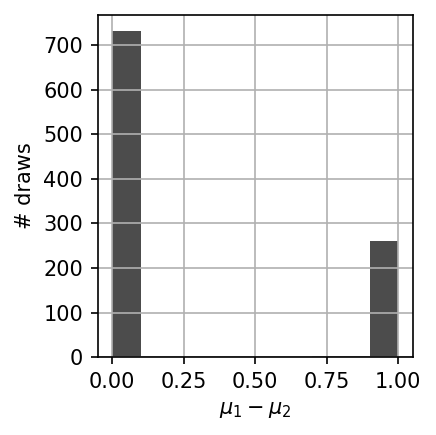

In [33]:
plt.figure(figsize=(3, 3))
plt.hist(res["diff"], bins=10, density=False, color="black", alpha=0.7)
plt.xlabel(r"$\mu_1 - \mu_2$")
plt.ylabel("# draws")
plt.grid(True)
plt.tight_layout()
plt.show()